# KVSwitch — Evaluation Results

Figures for the Evaluation section of the paper. Data from `results/exp/` produced by `exp/run_exp.sh`.

In [1]:
import json
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

os.chdir(
    Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
)

RESULTS_DIR = Path("results/exp")
FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- Styling ---
sns.set_theme(style="whitegrid")
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 7,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

BASELINE_COLORS = {
    "l4_ecmp": "tab:gray",
    "l7_rr": "tab:blue",
    "l7_pa": "tab:orange",
    "kvswitch": "tab:green",
}
BASELINE_LABELS = {
    "l4_ecmp": "L4-ECMP",
    "l7_rr": "L7-RR",
    "l7_pa": "L7-PA",
    "kvswitch": "KVSwitch",
}
BASELINE_MARKERS = {
    "l4_ecmp": "s",
    "l7_rr": "^",
    "l7_pa": "D",
    "kvswitch": "o",
}


def load_exp(subdir: str) -> dict:
    """Load the first result JSON from an experiment subdirectory."""
    d = RESULTS_DIR / subdir
    files = sorted(d.glob("eval_*.json"))
    assert files, f"No results in {d}"
    with open(files[0]) as f:
        return json.load(f)


def extract_summary(data: dict) -> dict[str, dict]:
    """Extract per-baseline summary dicts."""
    return {bl: info["summary"] for bl, info in data["results"].items()}


def compute_imbalance(data: dict, baseline: str) -> float:
    """Compute load imbalance factor (max/min worker request count)."""
    reqs = data["results"][baseline]["per_request"]
    workers: dict[str, int] = {}
    for r in reqs:
        w = r.get("worker_id") or "unknown"
        if w == "unknown":
            continue
        workers[w] = workers.get(w, 0) + 1
    if not workers:
        return 1.0
    counts = list(workers.values())
    return max(counts) / max(min(counts), 1)


print(f"Results dir: {RESULTS_DIR}")
print(f"Experiments: {sorted(p.name for p in RESULTS_DIR.iterdir() if p.is_dir())}")

Results dir: results/exp
Experiments: ['1_microbenchmark', '2_e2e', '3a_ecmp_ablation', '3b_warmup_ablation', '4a_prefix_sharing', '4b_kv_capacity', '4c_workers']


## Exp1: Microbenchmark

Per-request routing overhead at low load (10 req/s). Grouped bar chart of TTFT p50 and p95 per baseline.

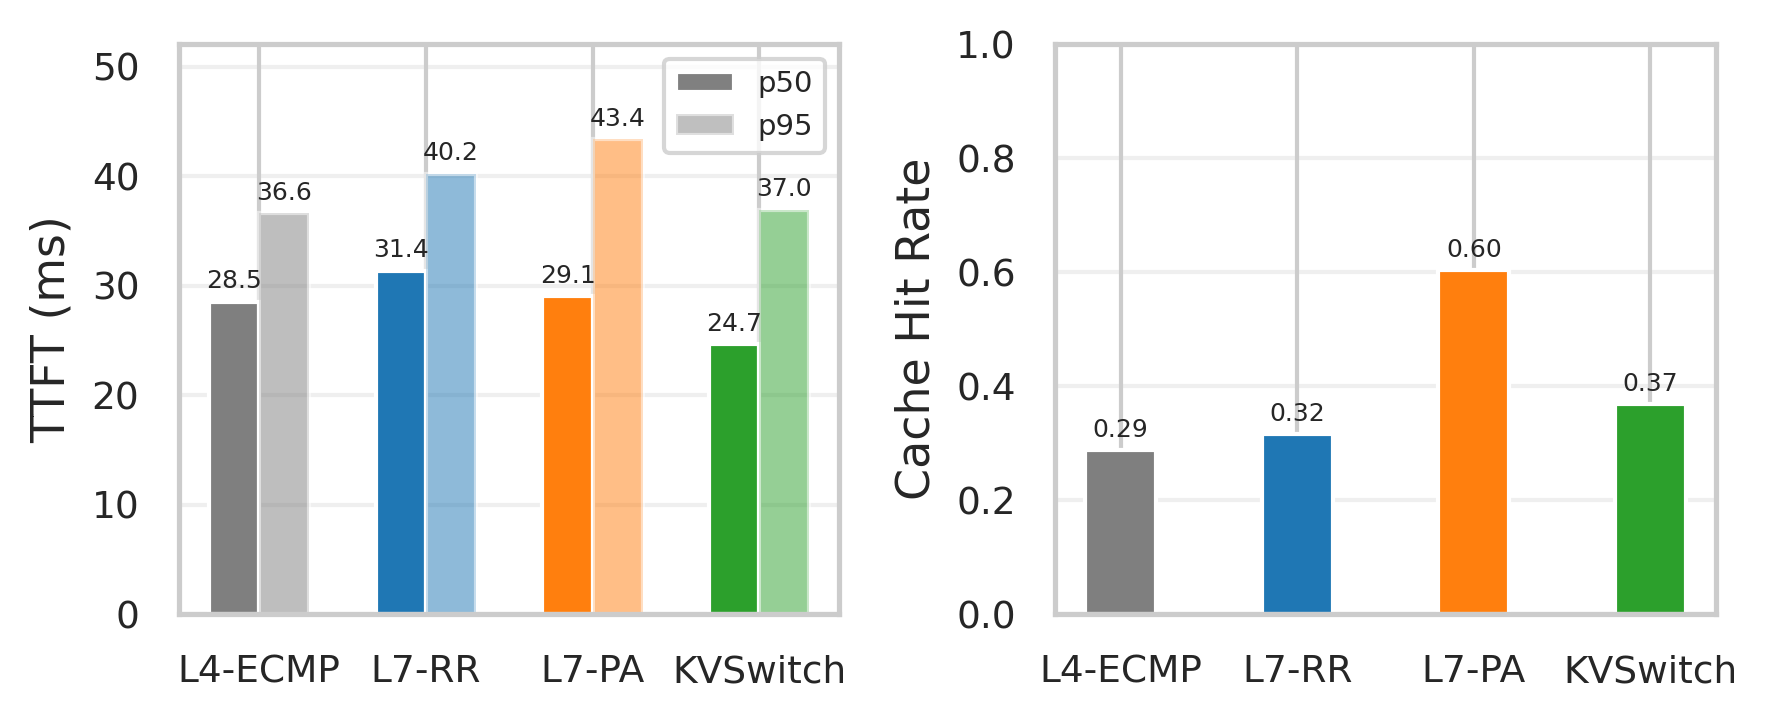

,Baseline,TTFT p50 (ms),TTFT p50 diff (ms),TTFT p50 diff (%),TTFT p95 (ms),TTFT p95 diff (ms),TTFT p95 diff (%),Cache hit rate,Cache diff (pp)
0,L4-ECMP,28.541857,3.887656,13.620893,36.636906,-0.320118,-0.873759,0.287863,-8.085166
1,L7-RR,31.365119,6.710918,21.396118,40.231095,3.274070,8.138158,0.315708,-5.300690
2,L7-PA,29.062713,4.408513,15.168965,43.393223,6.436198,14.832266,0.603469,23.475482
3,KVSwitch,24.654201,0.000000,0.000000,36.957025,0.000000,0.000000,0.368715,0.000000


In [2]:
exp1 = extract_summary(load_exp("1_microbenchmark"))
baselines = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.5))

# --- Left: TTFT p50 / p95 ---
x = np.arange(len(baselines))
w = 0.3
ttft_p50 = [exp1[bl]["ttft_p50_ms"] for bl in baselines]
ttft_p95 = [exp1[bl]["ttft_p95_ms"] for bl in baselines]

bars_p50 = ax1.bar(
    x - w / 2, ttft_p50, w, label="p50", color=[BASELINE_COLORS[bl] for bl in baselines]
)
bars_p95 = ax1.bar(
    x + w / 2,
    ttft_p95,
    w,
    label="p95",
    color=[BASELINE_COLORS[bl] for bl in baselines],
    alpha=0.5,
)

ax1.set_xticks(x)
ax1.set_xticklabels([BASELINE_LABELS[bl] for bl in baselines])
ax1.set_ylabel("TTFT (ms)")
ax1.set_ylim(0, max(ttft_p95) * 1.2)
ax1.bar_label(bars_p50, fmt="%.1f", fontsize=6, padding=2)
ax1.bar_label(bars_p95, fmt="%.1f", fontsize=6, padding=2)
ax1.legend(
    handles=[
        Patch(facecolor="gray", label="p50"),
        Patch(facecolor="gray", alpha=0.5, label="p95"),
    ],
    fontsize=7,
)
ax1.grid(True, axis="y", alpha=0.3)

# --- Right: Cache hit rate ---
cache_vals = [exp1[bl]["cache_hit_rate_mean"] for bl in baselines]
bars_cache = ax2.bar(
    x, cache_vals, 0.4, color=[BASELINE_COLORS[bl] for bl in baselines]
)
ax2.set_xticks(x)
ax2.set_xticklabels([BASELINE_LABELS[bl] for bl in baselines])
ax2.set_ylabel("Cache Hit Rate")
ax2.set_ylim(0, 1.0)
ax2.bar_label(bars_cache, fmt="%.2f", fontsize=6, padding=2)
ax2.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp1_routing_overhead.png")
fig.savefig(FIGURES_DIR / "exp1_routing_overhead.pdf")
plt.show()

# Print table
rows = []
kv = exp1["kvswitch"]
for bl in baselines:
    s = exp1[bl]
    ttft_50_diff = s["ttft_p50_ms"] - kv["ttft_p50_ms"]
    ttft_50_prc = ttft_50_diff / s["ttft_p50_ms"] * 100
    ttft_95_diff = s["ttft_p95_ms"] - kv["ttft_p95_ms"]
    ttft_95_prc = ttft_95_diff / s["ttft_p95_ms"] * 100
    cache_diff_pp = (s["cache_hit_rate_mean"] - kv["cache_hit_rate_mean"]) * 100
    rows.append(
        {
            "Baseline": BASELINE_LABELS[bl],
            "TTFT p50 (ms)": s["ttft_p50_ms"],
            "TTFT p50 diff (ms)": ttft_50_diff,
            "TTFT p50 diff (%)": ttft_50_prc,
            "TTFT p95 (ms)": s["ttft_p95_ms"],
            "TTFT p95 diff (ms)": ttft_95_diff,
            "TTFT p95 diff (%)": ttft_95_prc,
            "Cache hit rate": s["cache_hit_rate_mean"],
            "Cache diff (pp)": cache_diff_pp,
        }
    )
display(pd.DataFrame(rows))

## Exp 2: End-to-End Benchmark

TTFT p50, TTFT p95, cache hit rate, and load imbalance factor vs request rate.

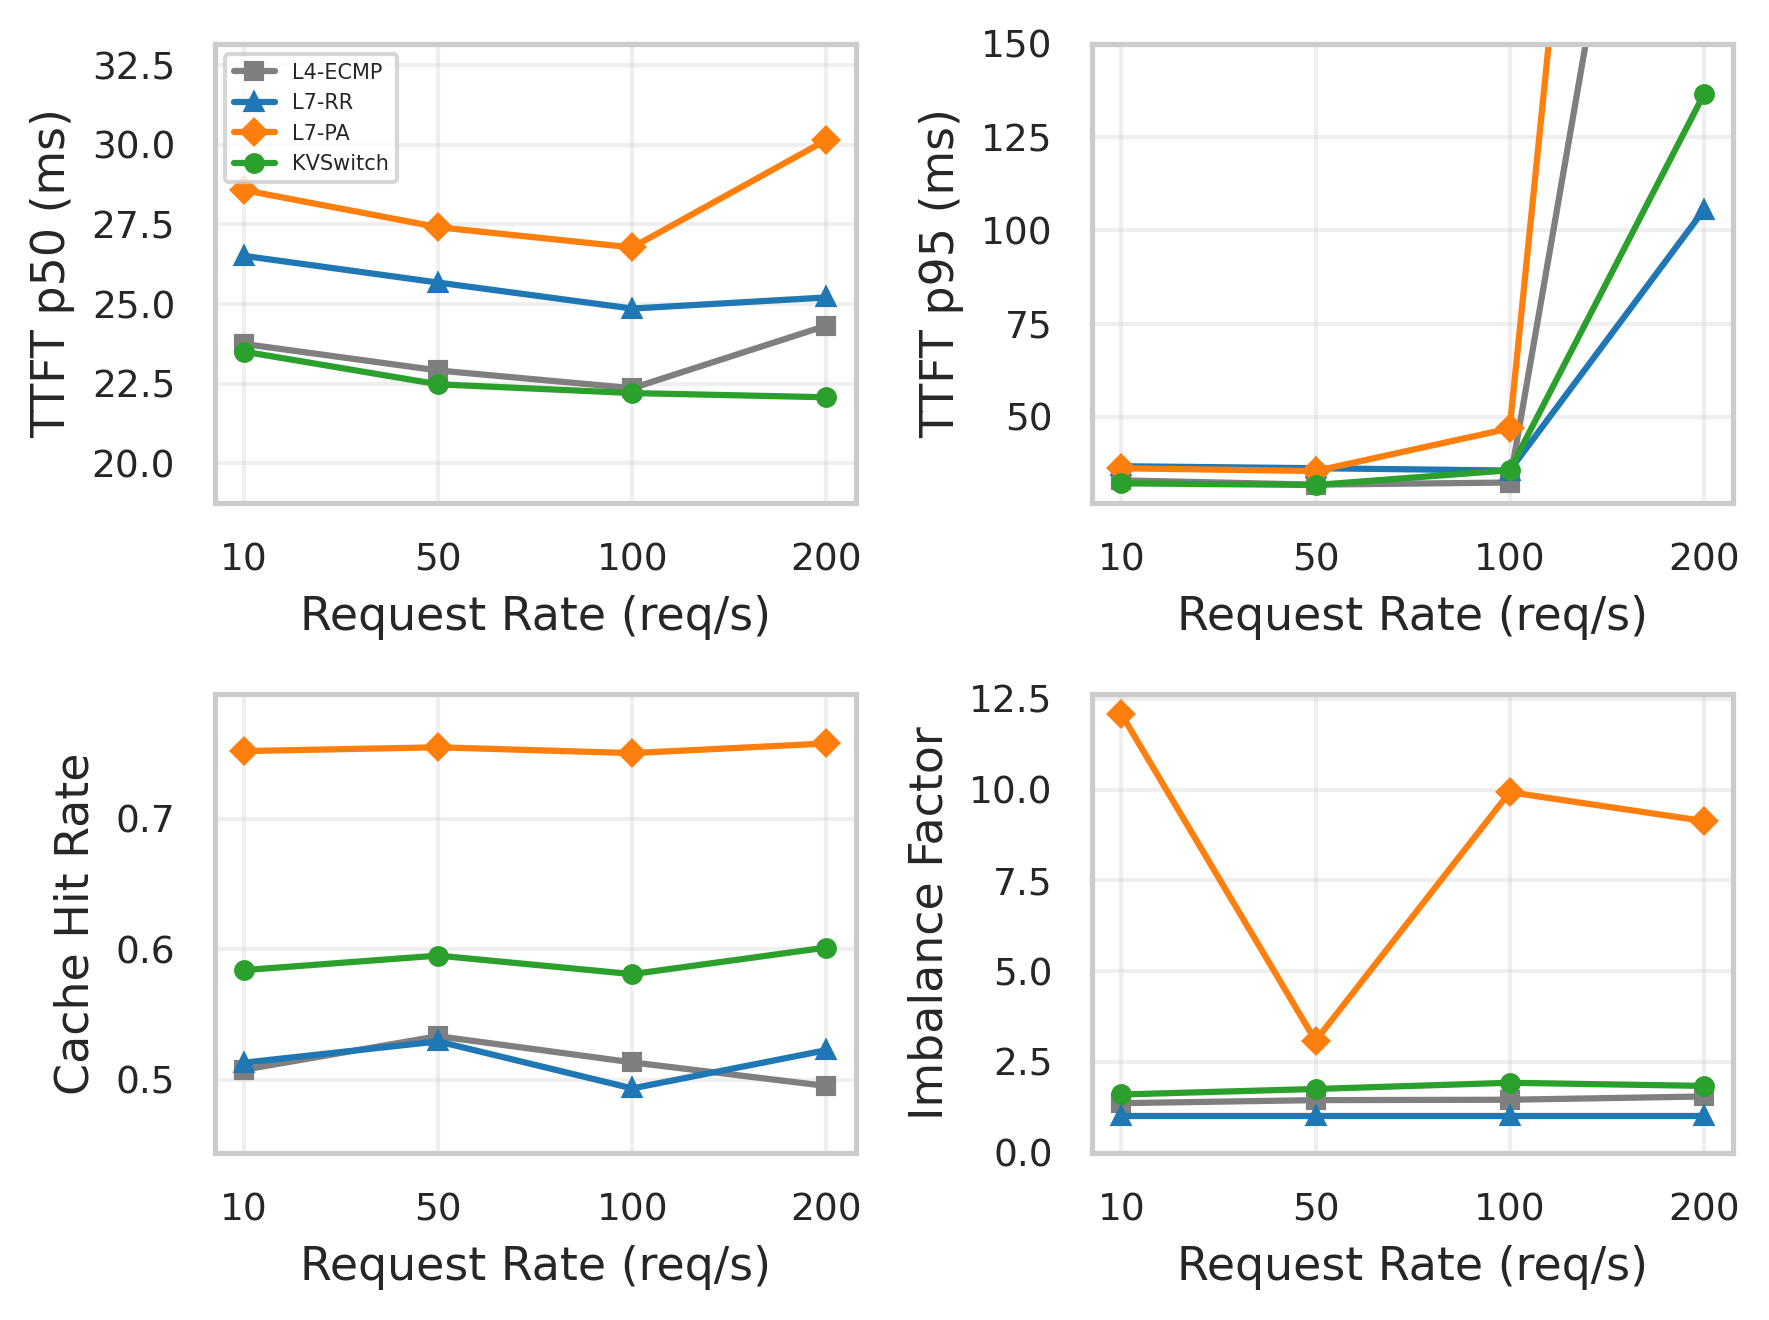

,Baseline,Rate,TTFT p50 (ms),TTFT p50 diff (ms),TTFT p50 diff (%),TTFT p95 (ms),TTFT p95 diff (ms),TTFT p95 diff (%),Cache hit rate,Cache diff (pp),Imbalance
0,L4-ECMP,10,23.747035,0.241180,1.015621,32.916445,0.805806,2.448036,0.507631,-7.638139,1.365385
1,L4-ECMP,50,22.913877,0.435065,1.898696,31.766266,0.090786,0.285793,0.533339,-6.179338,1.448980
2,L4-ECMP,100,22.356136,0.152271,0.681115,32.333957,-3.295368,-10.191662,0.513267,-6.765199,1.460000
3,L4-ECMP,200,24.321636,2.249606,9.249404,333.252682,196.752968,59.040175,0.495168,-10.614224,1.549020
4,L7-RR,10,26.512485,3.006629,11.340429,36.700240,4.589602,12.505645,0.513012,-7.100096,1.016129
5,L7-RR,50,25.674196,3.195384,12.445898,36.178819,4.503339,12.447446,0.529349,-6.578388,1.016129
6,L7-RR,100,24.857309,2.653444,10.674703,35.543672,-0.085653,-0.240979,0.493303,-8.761660,1.016129
7,L7-RR,200,25.206539,3.134509,12.435302,105.490939,-31.008775,-29.394728,0.522637,-7.867405,1.016129
8,L7-PA,10,28.579075,5.073219,17.751517,36.150535,4.039896,11.175205,0.751915,16.790197,12.076923
9,L7-PA,50,27.412834,4.934022,17.998948,35.418153,3.742672,10.567102,0.754829,15.969629,3.083333


In [3]:
rates = [10, 50, 100, 200]
baselines = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]

exp2_raw = {rate: load_exp(f"2_e2e/rate_{rate}") for rate in rates}
exp2 = {rate: extract_summary(data) for rate, data in exp2_raw.items()}

fig, axes = plt.subplots(2, 2, figsize=(6, 4.5))
x_pos = np.arange(len(rates))
x_labels = [str(r) for r in rates]

def _setup_rate_axis(ax: plt.Axes) -> None:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Request Rate (req/s)")

# TTFT p50
ax = axes[0, 0]
for bl in baselines:
    vals = [exp2[r][bl]["ttft_p50_ms"] for r in rates]
    ax.plot(
        x_pos, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4,
    )
_setup_rate_axis(ax)
ax.set_ylabel("TTFT p50 (ms)")
all_p50 = [exp2[r][bl]["ttft_p50_ms"] for r in rates for bl in baselines]
ax.set_ylim(min(all_p50) * 0.85, max(all_p50) * 1.1)
ax.legend(fontsize=5)
ax.grid(True, alpha=0.3)

# TTFT p95
ax = axes[0, 1]
for bl in baselines:
    vals = [exp2[r][bl]["ttft_p95_ms"] for r in rates]
    ax.plot(
        x_pos, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4,
    )
_setup_rate_axis(ax)
ax.set_ylabel("TTFT p95 (ms)")
all_p95 = [exp2[r][bl]["ttft_p95_ms"] for r in rates for bl in baselines]
ax.set_ylim(min(all_p95) * 0.85, 150)
ax.grid(True, alpha=0.3)

# Cache hit rate
ax = axes[1, 0]
for bl in baselines:
    vals = [exp2[r][bl]["cache_hit_rate_mean"] for r in rates]
    ax.plot(
        x_pos, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4,
    )
_setup_rate_axis(ax)
ax.set_ylabel("Cache Hit Rate")
all_cache = [exp2[r][bl]["cache_hit_rate_mean"] for r in rates for bl in baselines]
ax.set_ylim(min(all_cache) * 0.9, min(max(all_cache) * 1.05, 1.0))
ax.grid(True, alpha=0.3)

# Load imbalance factor
ax = axes[1, 1]
for bl in baselines:
    vals = [compute_imbalance(exp2_raw[r], bl) for r in rates]
    ax.plot(
        x_pos, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4,
    )
_setup_rate_axis(ax)
ax.set_ylabel("Imbalance Factor")
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp2_rate_sweep.png")
fig.savefig(FIGURES_DIR / "exp2_rate_sweep.pdf")
plt.show()

# Print table
rows = []
for bl in baselines:
    for rate in rates:
        kv = exp2[rate]["kvswitch"]
        s = exp2[rate][bl]
        imb = compute_imbalance(exp2_raw[rate], bl)
        ttft_p50_diff = s["ttft_p50_ms"] - kv["ttft_p50_ms"]
        ttft_p50_prc = ttft_p50_diff / s["ttft_p50_ms"] * 100
        ttft_p95_diff = s["ttft_p95_ms"] - kv["ttft_p95_ms"]
        ttft_p95_prc = ttft_p95_diff / s["ttft_p95_ms"] * 100
        cache_diff_pp = (s["cache_hit_rate_mean"] - kv["cache_hit_rate_mean"]) * 100
        rows.append(
            {
                "Baseline": BASELINE_LABELS[bl],
                "Rate": rate,
                "TTFT p50 (ms)": s["ttft_p50_ms"],
                "TTFT p50 diff (ms)": ttft_p50_diff,
                "TTFT p50 diff (%)": ttft_p50_prc,
                "TTFT p95 (ms)": s["ttft_p95_ms"],
                "TTFT p95 diff (ms)": ttft_p95_diff,
                "TTFT p95 diff (%)": ttft_p95_prc,
                "Cache hit rate": s["cache_hit_rate_mean"],
                "Cache diff (pp)": cache_diff_pp,
                "Imbalance": imb,
            }
        )
display(pd.DataFrame(rows))

## Exp 3: Ablation — ECMP vs Pinning and Warm-up Impact

Left: Per-prefix ECMP vs single-worker pinning under resource constraints.
Right: With vs without warm-up at 200 req/s.

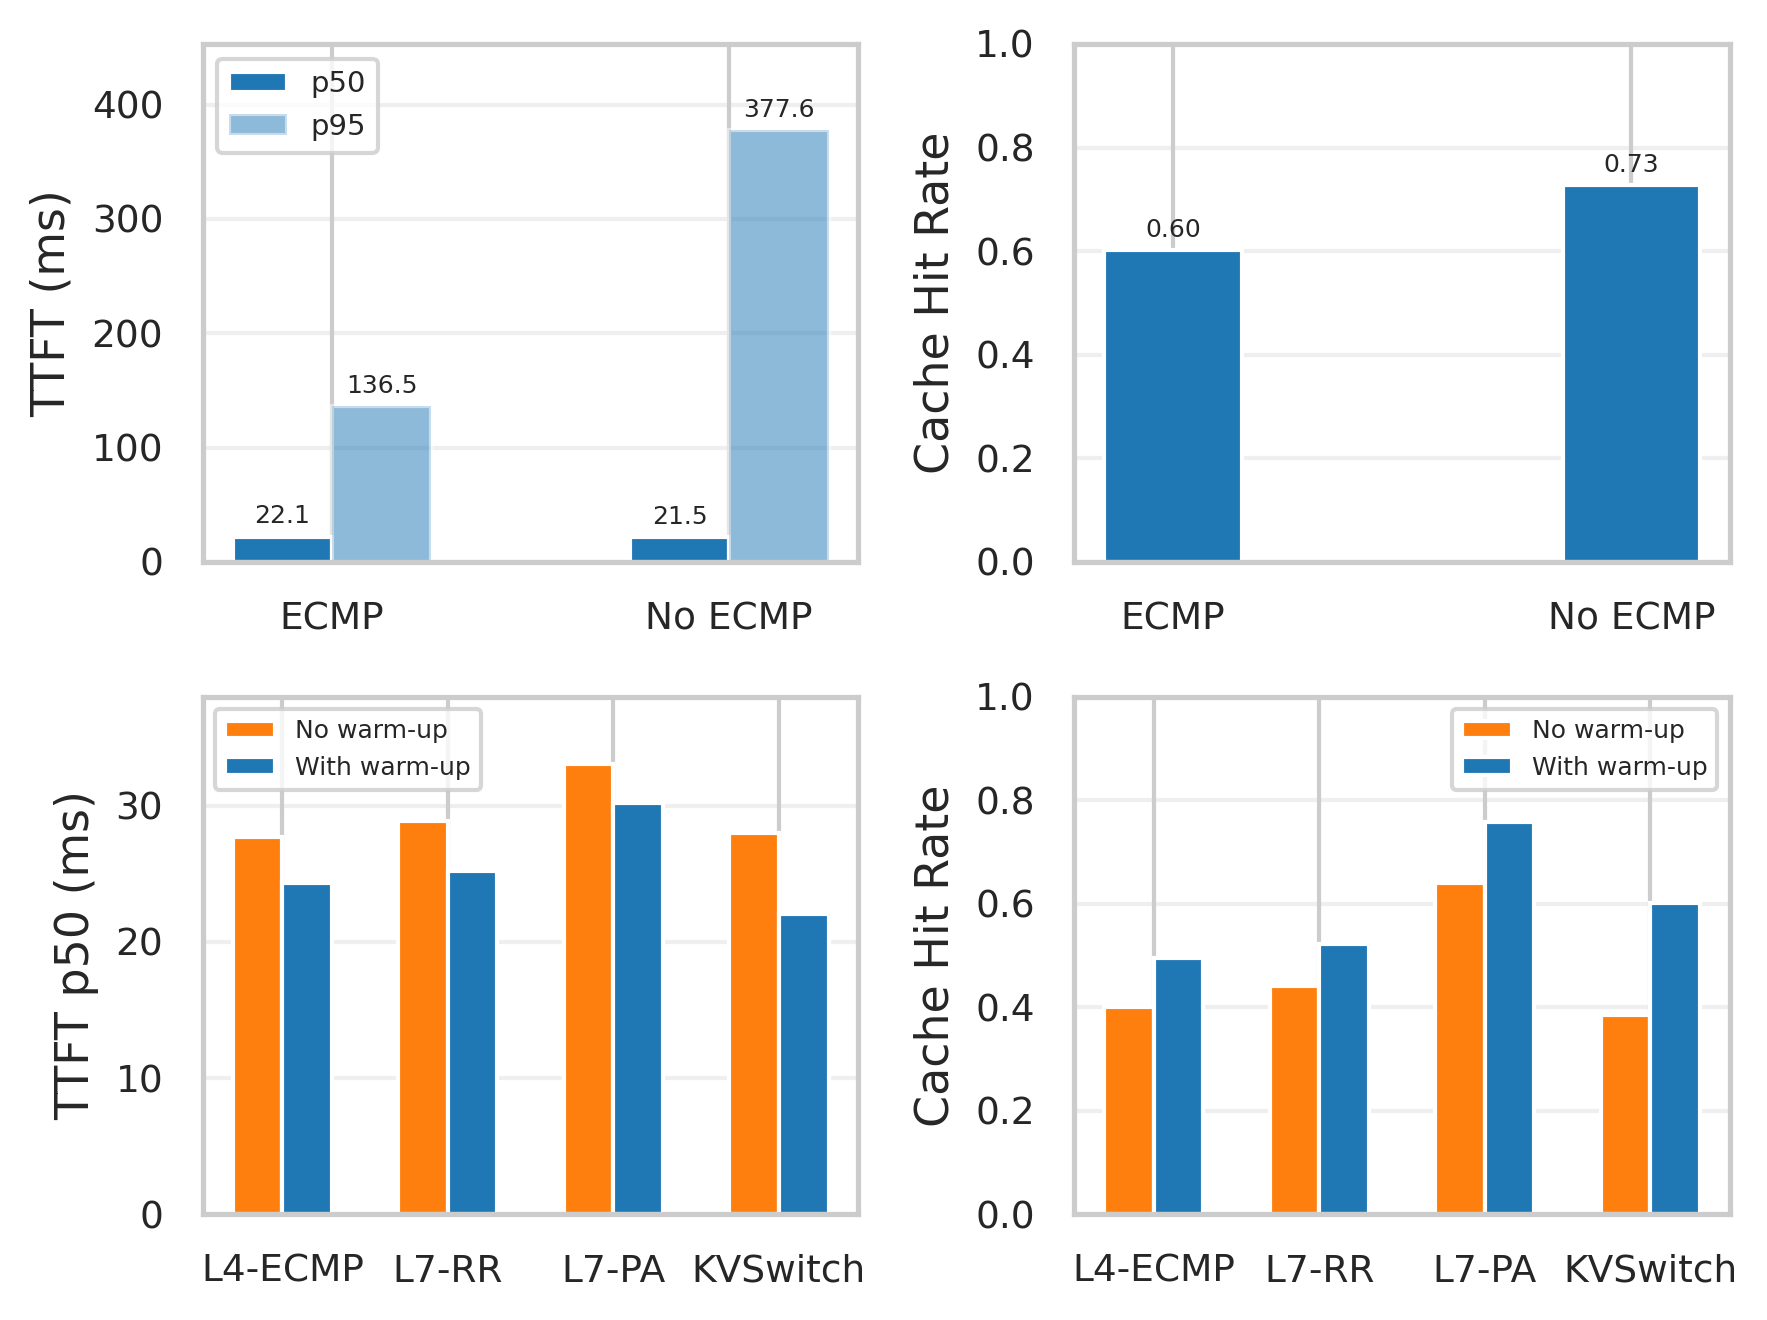

,Config,TTFT p50 (ms),TTFT p95 (ms),Cache hit rate,Cache diff (pp)
0,ECMP,22.072030,136.499714,0.601311,0.000000
1,No ECMP,21.528147,377.575590,0.728053,12.674201


,Baseline,Warmup TTFT p50 (ms),No-WU TTFT p50 (ms),Warmup cache,No-WU cache,Cache diff (pp)
0,L4-ECMP,24.321636,27.726261,0.495168,0.399745,-9.542371
1,L7-RR,25.206539,28.842656,0.522637,0.440081,-8.255537
2,L7-PA,30.151136,33.055448,0.757745,0.640142,-11.760293
3,KVSwitch,22.072030,27.983344,0.601311,0.385838,-21.547278


In [4]:
# 3a: ECMP (from E2 at 200rps) vs Pinning
exp3a_pin = extract_summary(load_exp("3a_ecmp_ablation/pin"))
exp2_200_ecmp = extract_summary(load_exp("2_e2e/rate_200"))

# 3b: Warmup vs no-warmup at 200 req/s
exp3b_no = extract_summary(load_exp("3b_warmup_ablation/no_warmup"))

fig, axes = plt.subplots(2, 2, figsize=(6, 4.5))

# --- Top-left: 3a TTFT p50/p95 ---
ax = axes[0, 0]
configs = ["ECMP", "No ECMP"]
ttft_p50 = [exp2_200_ecmp["kvswitch"]["ttft_p50_ms"], exp3a_pin["kvswitch"]["ttft_p50_ms"]]
ttft_p95 = [exp2_200_ecmp["kvswitch"]["ttft_p95_ms"], exp3a_pin["kvswitch"]["ttft_p95_ms"]]
x = np.arange(len(configs))
w = 0.25
b1 = ax.bar(x - w / 2, ttft_p50, w, label="p50", color="tab:blue")
b2 = ax.bar(x + w / 2, ttft_p95, w, label="p95", color="tab:blue", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel("TTFT (ms)")
ax.set_ylim(0, max(ttft_p95) * 1.2)
ax.bar_label(b1, fmt="%.1f", fontsize=6, padding=2)
ax.bar_label(b2, fmt="%.1f", fontsize=6, padding=2)
ax.legend(handles=[Patch(facecolor="tab:blue", label="p50"), Patch(facecolor="tab:blue", alpha=0.5, label="p95")], fontsize=7)
ax.grid(True, axis="y", alpha=0.3)

# --- Top-right: 3a Cache hit rate ---
ax = axes[0, 1]
cache_3a = [exp2_200_ecmp["kvswitch"]["cache_hit_rate_mean"], exp3a_pin["kvswitch"]["cache_hit_rate_mean"]]
bars = ax.bar(x, cache_3a, 0.3, color="tab:blue")
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel("Cache Hit Rate")
ax.set_ylim(0, 1.0)
ax.bar_label(bars, fmt="%.2f", fontsize=6, padding=2)
ax.grid(True, axis="y", alpha=0.3)

# --- Bottom-left: 3b TTFT p50 warmup vs no-warmup ---
ax = axes[1, 0]
baselines_3b = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]
x3b = np.arange(len(baselines_3b))
w = 0.3
warmup_p50 = [exp2_200_ecmp[bl]["ttft_p50_ms"] for bl in baselines_3b]
no_warmup_p50 = [exp3b_no[bl]["ttft_p50_ms"] for bl in baselines_3b]
ax.bar(x3b - w / 2, no_warmup_p50, w, label="No warm-up", color="tab:orange")
ax.bar(x3b + w / 2, warmup_p50, w, label="With warm-up", color="tab:blue")
ax.set_xticks(x3b)
ax.set_xticklabels([BASELINE_LABELS[bl] for bl in baselines_3b])
ax.set_ylabel("TTFT p50 (ms)")
ax.set_ylim(0, 38)
ax.legend(fontsize=6)
ax.grid(True, axis="y", alpha=0.3)

# --- Bottom-right: 3b Cache hit rate warmup vs no-warmup ---
ax = axes[1, 1]
warmup_cache = [exp2_200_ecmp[bl]["cache_hit_rate_mean"] for bl in baselines_3b]
no_warmup_cache = [exp3b_no[bl]["cache_hit_rate_mean"] for bl in baselines_3b]
ax.bar(x3b - w / 2, no_warmup_cache, w, label="No warm-up", color="tab:orange")
ax.bar(x3b + w / 2, warmup_cache, w, label="With warm-up", color="tab:blue")
ax.set_xticks(x3b)
ax.set_xticklabels([BASELINE_LABELS[bl] for bl in baselines_3b])
ax.set_ylabel("Cache Hit Rate")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=6)
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp3_ablation.png")
fig.savefig(FIGURES_DIR / "exp3_ablation.pdf")
plt.show()

# --- 3a table ---
ecmp = exp2_200_ecmp["kvswitch"]
rows_3a = []
for name, s in [("ECMP", ecmp), ("No ECMP", exp3a_pin["kvswitch"])]:
    cache_diff_pp = (s["cache_hit_rate_mean"] - ecmp["cache_hit_rate_mean"]) * 100
    rows_3a.append({"Config": name, "TTFT p50 (ms)": s["ttft_p50_ms"], "TTFT p95 (ms)": s["ttft_p95_ms"], "Cache hit rate": s["cache_hit_rate_mean"], "Cache diff (pp)": cache_diff_pp})
display(pd.DataFrame(rows_3a))

# --- 3b table ---
rows_3b = []
for bl in baselines_3b:
    sw = exp2_200_ecmp[bl]
    sn = exp3b_no[bl]
    cache_diff_pp = (sn["cache_hit_rate_mean"] - sw["cache_hit_rate_mean"]) * 100
    rows_3b.append({"Baseline": BASELINE_LABELS[bl], "Warmup TTFT p50 (ms)": sw["ttft_p50_ms"], "No-WU TTFT p50 (ms)": sn["ttft_p50_ms"], "Warmup cache": sw["cache_hit_rate_mean"], "No-WU cache": sn["cache_hit_rate_mean"], "Cache diff (pp)": cache_diff_pp})
display(pd.DataFrame(rows_3b))

## Exp 4a: Prefix Sharing Sensitivity

Cache hit rate and TTFT p50 vs prefix sharing ratio at 10 req/s.

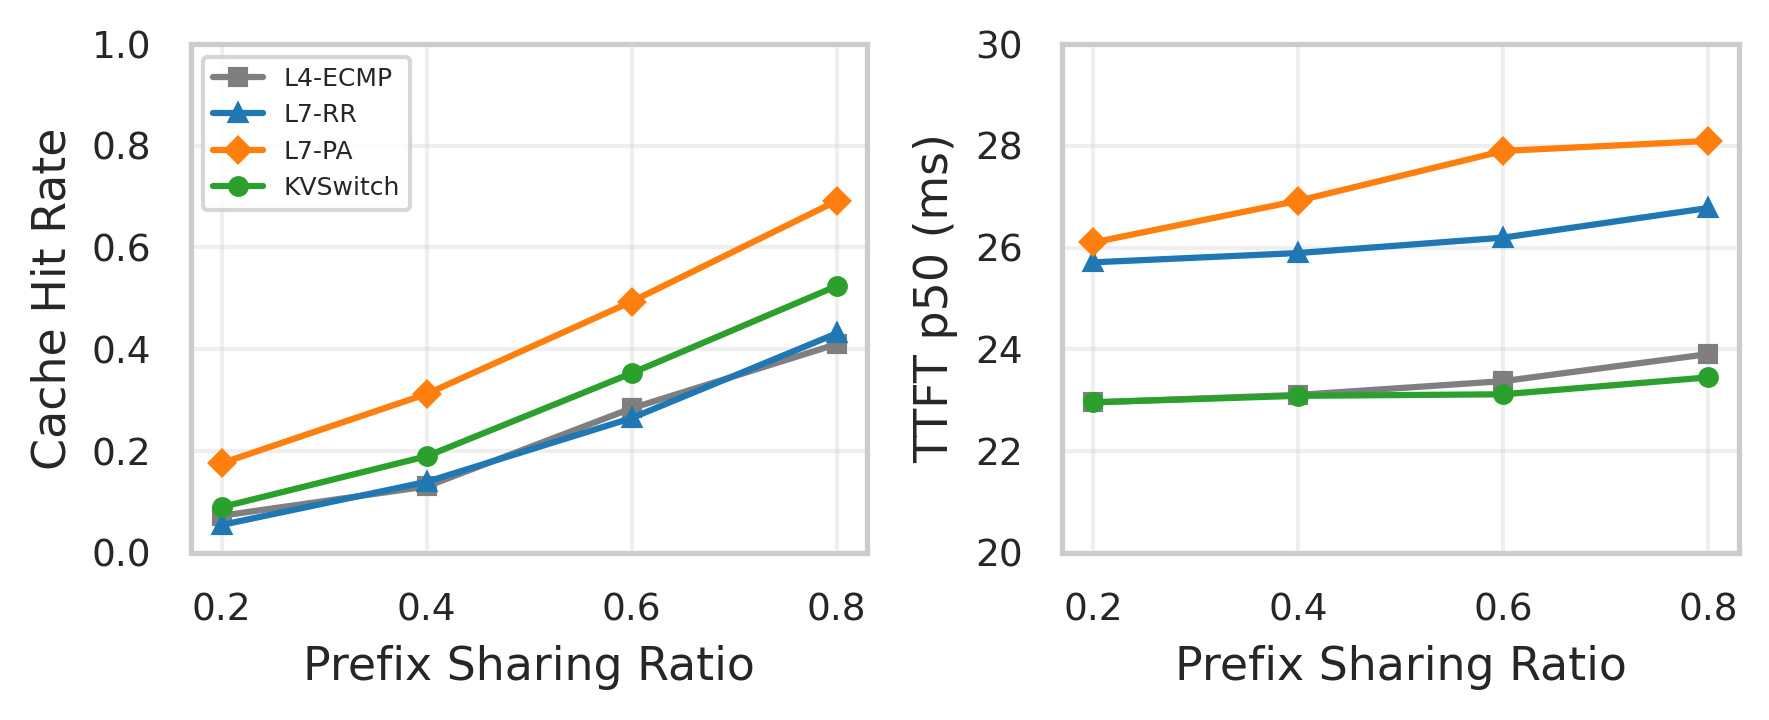

,Baseline,Ratio,TTFT p50 (ms),TTFT p50 diff (ms),TTFT p50 diff (%),Cache hit rate,Cache diff (pp)
0,L4-ECMP,0.2,22.955831,-0.000501,-0.002181,0.072804,-1.686987
1,L4-ECMP,0.4,23.102271,0.017477,0.075649,0.130263,-5.941506
2,L4-ECMP,0.6,23.373400,0.258719,1.106893,0.283959,-6.899681
3,L4-ECMP,0.8,23.904762,0.457668,1.914549,0.410086,-11.423831
4,L7-RR,0.2,25.707940,2.751608,10.703339,0.054636,-3.503707
5,L7-RR,0.4,25.891258,2.806463,10.839423,0.139351,-5.032688
6,L7-RR,0.6,26.193938,3.079256,11.755607,0.264761,-8.819538
7,L7-RR,0.8,26.776193,3.329099,12.433056,0.431149,-9.317551
8,L7-PA,0.2,26.099087,3.142755,12.041629,0.176002,8.632892
9,L7-PA,0.4,26.918863,3.834068,14.243054,0.312139,12.246104


In [5]:
ratios = [0.2, 0.4, 0.6, 0.8]
baselines_4a = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]

exp4a = {r: extract_summary(load_exp(f"4a_prefix_sharing/ratio_{r}")) for r in ratios}

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

# Cache hit rate
ax = axes[0]
for bl in baselines_4a:
    vals = [exp4a[r][bl]["cache_hit_rate_mean"] for r in ratios]
    ax.plot(
        ratios,
        vals,
        marker=BASELINE_MARKERS[bl],
        color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl],
        linewidth=1.5,
        markersize=4,
    )
ax.set_xlabel("Prefix Sharing Ratio")
ax.set_ylabel("Cache Hit Rate")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# TTFT p50
ax = axes[1]
for bl in baselines_4a:
    vals = [exp4a[r][bl]["ttft_p50_ms"] for r in ratios]
    ax.plot(
        ratios,
        vals,
        marker=BASELINE_MARKERS[bl],
        color=BASELINE_COLORS[bl],
        label=BASELINE_LABELS[bl],
        linewidth=1.5,
        markersize=4,
    )
ax.set_xlabel("Prefix Sharing Ratio")
ax.set_ylabel("TTFT p50 (ms)")
ax.set_ylim(20, 30)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp4a_prefix_sharing.png")
fig.savefig(FIGURES_DIR / "exp4a_prefix_sharing.pdf")
plt.show()

# Print table
rows = []
for bl in baselines_4a:
    for r in ratios:
        kv = exp4a[r]["kvswitch"]
        s = exp4a[r][bl]
        ttft_p50_diff = s["ttft_p50_ms"] - kv["ttft_p50_ms"]
        ttft_p50_prc = ttft_p50_diff / s["ttft_p50_ms"] * 100 if s["ttft_p50_ms"] else 0
        cache_diff_pp = (s["cache_hit_rate_mean"] - kv["cache_hit_rate_mean"]) * 100
        rows.append(
            {
                "Baseline": BASELINE_LABELS[bl],
                "Ratio": r,
                "TTFT p50 (ms)": s["ttft_p50_ms"],
                "TTFT p50 diff (ms)": ttft_p50_diff,
                "TTFT p50 diff (%)": ttft_p50_prc,
                "Cache hit rate": s["cache_hit_rate_mean"],
                "Cache diff (pp)": cache_diff_pp,
            }
        )
display(pd.DataFrame(rows))

## Exp 4b: KV Cache Capacity Sensitivity

Cache hit rate, TTFT p50, and TTFT p95 vs KV cache capacity at 200 req/s.

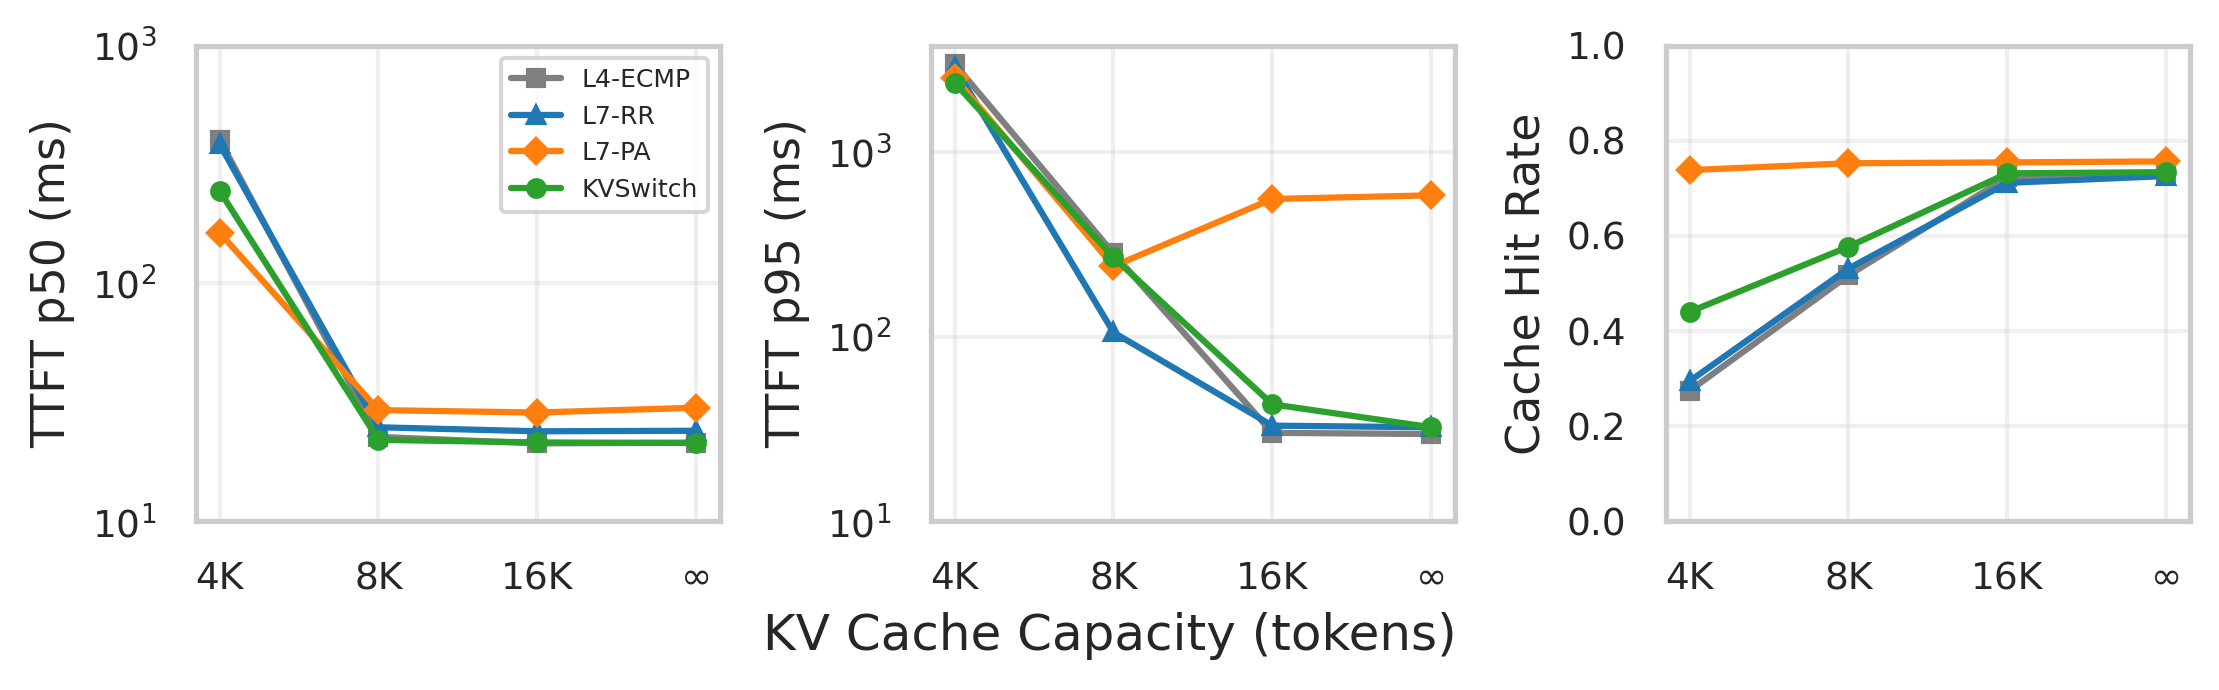

,Baseline,Capacity,TTFT p50 (ms),TTFT p50 diff (ms),TTFT p50 diff (%),TTFT p95 (ms),TTFT p95 diff (ms),TTFT p95 diff (%),Cache hit rate,Cache diff (pp)
0,L4-ECMP,4K,402.331240,157.396807,39.121199,3006.046329,623.570848,20.743887,0.274699,-16.569930
1,L4-ECMP,8K,22.655819,0.635623,2.805560,283.212101,13.741755,4.852107,0.517099,-6.011726
2,L4-ECMP,16K,21.282999,-0.189918,-0.892348,30.189781,-12.908140,-42.756654,0.723353,-0.806079
3,L4-ECMP,∞,21.415500,0.056066,0.261800,29.739699,-2.647345,-8.901719,0.731704,-0.231091
4,L7-RR,4K,384.658980,139.724547,36.324265,2889.889773,507.414292,17.558258,0.294822,-14.557572
5,L7-RR,8K,24.869977,2.849780,11.458717,105.662981,-163.807366,-155.028151,0.531348,-4.586864
6,L7-RR,16K,23.919965,2.447048,10.230149,33.023837,-10.074085,-30.505495,0.711385,-2.002951
7,L7-RR,∞,24.046007,2.686573,11.172635,32.363403,-0.023641,-0.073048,0.725817,-0.819757
8,L7-PA,4K,163.388389,-81.546044,-49.909326,2537.839784,155.364303,6.121911,0.738258,29.786008
9,L7-PA,8K,29.358696,7.338500,24.996000,241.386678,-28.083668,-11.634307,0.752655,17.543856


In [15]:
caps = [4096, 8192, 16384]
cap_labels = ["4K", "8K", "16K", "∞"]
baselines_4b = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]

exp4b = {}
for cap in caps:
    exp4b[cap] = extract_summary(load_exp(f"4b_kv_capacity/cap_{cap}"))
exp4b["unlimited"] = extract_summary(load_exp("4b_kv_capacity/cap_unlimited"))

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))

x_vals = list(range(len(cap_labels)))
keys = caps + ["unlimited"]

# TTFT p50
ax = axes[0]
for bl in baselines_4b:
    vals = [exp4b[k][bl]["ttft_p50_ms"] for k in keys]
    ax.plot(x_vals, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_xticks(x_vals)
ax.set_xticklabels(cap_labels)
ax.set_ylabel("TTFT p50 (ms)")
ax.set_yscale("log")
ax.set_ylim(10, 1000)
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# TTFT p95
ax = axes[1]
for bl in baselines_4b:
    vals = [exp4b[k][bl]["ttft_p95_ms"] for k in keys]
    ax.plot(x_vals, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_xticks(x_vals)
ax.set_xticklabels(cap_labels)
ax.set_ylabel("TTFT p95 (ms)")
ax.set_yscale("log")
ax.set_ylim(10, None)
ax.grid(True, alpha=0.3)

# Cache hit rate
ax = axes[2]
for bl in baselines_4b:
    vals = [exp4b[k][bl]["cache_hit_rate_mean"] for k in keys]
    ax.plot(x_vals, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_xticks(x_vals)
ax.set_xticklabels(cap_labels)
ax.set_ylabel("Cache Hit Rate")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

fig.supxlabel("KV Cache Capacity (tokens)", y=0.1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp4b_kv_capacity.png")
fig.savefig(FIGURES_DIR / "exp4b_kv_capacity.pdf")
plt.show()

# Print table
rows = []
for bl in baselines_4b:
    for cap, label in zip(keys, cap_labels):
        kv = exp4b[cap]["kvswitch"]
        s = exp4b[cap][bl]
        ttft_p50_diff = s["ttft_p50_ms"] - kv["ttft_p50_ms"]
        ttft_p50_prc = ttft_p50_diff / s["ttft_p50_ms"] * 100 if s["ttft_p50_ms"] else 0
        ttft_p95_diff = s["ttft_p95_ms"] - kv["ttft_p95_ms"]
        ttft_p95_prc = ttft_p95_diff / s["ttft_p95_ms"] * 100 if s["ttft_p95_ms"] else 0
        cache_diff_pp = (s["cache_hit_rate_mean"] - kv["cache_hit_rate_mean"]) * 100
        rows.append(
            {
                "Baseline": BASELINE_LABELS[bl],
                "Capacity": label,
                "TTFT p50 (ms)": s["ttft_p50_ms"],
                "TTFT p50 diff (ms)": ttft_p50_diff,
                "TTFT p50 diff (%)": ttft_p50_prc,
                "TTFT p95 (ms)": s["ttft_p95_ms"],
                "TTFT p95 diff (ms)": ttft_p95_diff,
                "TTFT p95 diff (%)": ttft_p95_prc,
                "Cache hit rate": s["cache_hit_rate_mean"],
                "Cache diff (pp)": cache_diff_pp,
            }
        )
display(pd.DataFrame(rows))

## Exp 4c: Number of Workers Scalability

TTFT p50, TTFT p95, and cache hit rate vs number of workers at 200 req/s.

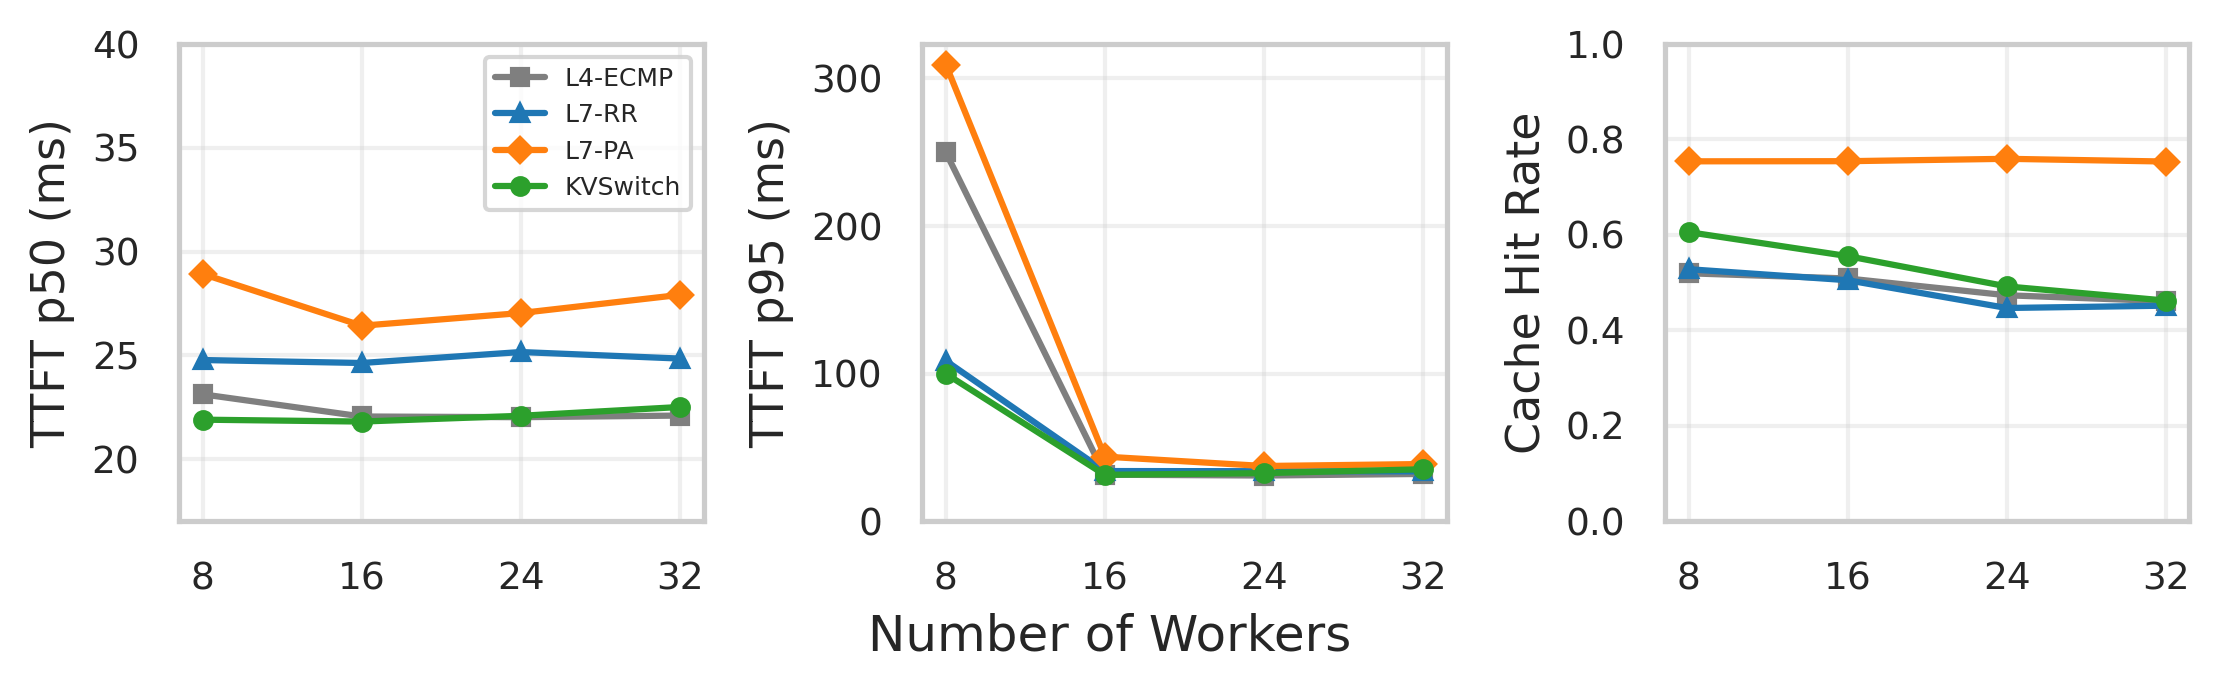

,Baseline,Workers,TTFT p50 (ms),TTFT p50 diff (ms),TTFT p50 diff (%),TTFT p95 (ms),TTFT p95 diff (ms),TTFT p95 diff (%),Cache hit rate,Cache diff (pp),Imbalance
0,L4-ECMP,8,23.122418,1.220805,5.279747,249.984954,149.968063,59.990836,0.519689,-8.624153,1.267857
1,L4-ECMP,16,22.055079,0.244612,1.109095,31.631561,0.070825,0.223905,0.508887,-4.680534,1.857143
2,L4-ECMP,24,22.021042,-0.067699,-0.307429,31.077907,-1.626968,-5.235126,0.473693,-1.859894,2.818182
3,L4-ECMP,32,22.098852,-0.413114,-1.869389,32.154034,-3.150447,-9.797984,0.461329,-0.128441,2.272727
4,L7-RR,8,24.775033,2.873420,11.598047,108.783639,8.766748,8.058885,0.528279,-7.765080,1.016129
5,L7-RR,16,24.632109,2.821642,11.455137,34.109387,2.548650,7.471990,0.505165,-5.052795,1.032258
6,L7-RR,24,25.160711,3.071970,12.209392,34.015208,1.310333,3.852198,0.447030,-4.526172,1.050000
7,L7-RR,32,24.845517,2.333552,9.392245,33.883948,-1.420533,-4.192349,0.451888,-1.072584,1.066667
8,L7-PA,8,28.918262,7.016649,24.263730,309.401210,209.384319,67.674047,0.754256,14.832549,10.000000
9,L7-PA,16,26.428199,4.617732,17.472745,43.878682,12.317946,28.072734,0.754530,19.883709,11.428571


In [10]:
n_workers_list = [8, 16, 24, 32]
baselines_4c = ["l4_ecmp", "l7_rr", "l7_pa", "kvswitch"]

exp4c_raw = {nw: load_exp(f"4c_workers/workers_{nw}") for nw in n_workers_list}
exp4c = {nw: extract_summary(data) for nw, data in exp4c_raw.items()}

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))

# TTFT p50
ax = axes[0]
for bl in baselines_4c:
    vals = [exp4c[nw][bl]["ttft_p50_ms"] for nw in n_workers_list]
    ax.plot(n_workers_list, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_ylabel("TTFT p50 (ms)")
ax.set_xticks(n_workers_list)
ax.set_ylim(17, 40)
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# TTFT p95
ax = axes[1]
for bl in baselines_4c:
    vals = [exp4c[nw][bl]["ttft_p95_ms"] for nw in n_workers_list]
    ax.plot(n_workers_list, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_ylabel("TTFT p95 (ms)")
ax.set_xticks(n_workers_list)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

# Cache hit rate
ax = axes[2]
for bl in baselines_4c:
    vals = [exp4c[nw][bl]["cache_hit_rate_mean"] for nw in n_workers_list]
    ax.plot(n_workers_list, vals, marker=BASELINE_MARKERS[bl], color=BASELINE_COLORS[bl],
            label=BASELINE_LABELS[bl], linewidth=1.5, markersize=4)
ax.set_ylabel("Cache Hit Rate")
ax.set_xticks(n_workers_list)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

fig.supxlabel("Number of Workers", y=0.1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exp4c_workers.png")
fig.savefig(FIGURES_DIR / "exp4c_workers.pdf")
plt.show()

# Print table
rows = []
for bl in baselines_4c:
    for nw in n_workers_list:
        kv = exp4c[nw]["kvswitch"]
        s = exp4c[nw][bl]
        imb = compute_imbalance(exp4c_raw[nw], bl)
        ttft_p50_diff = s["ttft_p50_ms"] - kv["ttft_p50_ms"]
        ttft_p50_prc = ttft_p50_diff / s["ttft_p50_ms"] * 100 if s["ttft_p50_ms"] else 0
        ttft_p95_diff = s["ttft_p95_ms"] - kv["ttft_p95_ms"]
        ttft_p95_prc = ttft_p95_diff / s["ttft_p95_ms"] * 100 if s["ttft_p95_ms"] else 0
        cache_diff_pp = (s["cache_hit_rate_mean"] - kv["cache_hit_rate_mean"]) * 100
        rows.append(
            {
                "Baseline": BASELINE_LABELS[bl],
                "Workers": nw,
                "TTFT p50 (ms)": s["ttft_p50_ms"],
                "TTFT p50 diff (ms)": ttft_p50_diff,
                "TTFT p50 diff (%)": ttft_p50_prc,
                "TTFT p95 (ms)": s["ttft_p95_ms"],
                "TTFT p95 diff (ms)": ttft_p95_diff,
                "TTFT p95 diff (%)": ttft_p95_prc,
                "Cache hit rate": s["cache_hit_rate_mean"],
                "Cache diff (pp)": cache_diff_pp,
                "Imbalance": imb,
            }
        )
display(pd.DataFrame(rows))